# TPM vs. VST

Up until 6/2/2026, I've been using variance stabilized transformed (VST) expression for comparing expression of genes across samples. I'm starting to think TPM is better because it normalizes for both library size and gene length.

## 1. load libraries

In [2]:
library(tidyverse)

## 2. load csvs

### counts matrix from `featureCounts`

In [4]:
counts <- read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ce24_rnaseq/newRef_featureCounts/featureCounts_matrix.csv')
head(counts)

,Gene_ID,Length,B1_B1_O01,B1_Nu_O03,B1_W5_O50,B2_B5_O51,B2_C4_O40,B2_Nu_O12,B3_B4_O41,B3_C3_O30,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_Nu_G41,W6_Nu_G45,W6_W3_G36,W6_W4_G48
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,LOC144621260,36658,2626,2649,2072,2158,2074,3974,1207,1181,⋯,1252,2294,2215,1653,1720,1566,2734,2374,2683,2391
2,LOC144621269,25160,55,580,1632,2484,1011,20011,2110,886,⋯,6,620,44,101,9226,16,2,4034,383,9803
3,LOC111120925,3392,70,4,23,469,11,18,15,7,⋯,3,452,82,28,5,1,0,11,11,9
4,Trnae-cuc,72,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,Trnae-cuc-2,72,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,Trnae-cuc-3,72,0,0,0,0,0,1,0,0,⋯,0,0,0,0,0,0,0,0,0,0


### sample meta data

In [39]:
meta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv')
head(meta)

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1
2,B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA
3,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5
4,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5
5,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4
6,B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA


## 3. calculate TPM
transcripts per million (TPM) normalizes for library size *and* gene length

### A. create named vector
gene name : gene length

In [24]:
gene_lengths <- setNames(counts$Length, counts$Gene_ID)
head(gene_lengths)

LOC144621260 LOC144621269 LOC111120925    Trnae-cuc  Trnae-cuc-2  Trnae-cuc-3 
       36658        25160         3392           72           72           72

### B. create counts matrix

In [19]:
# generate matrix of only gene x sample
counts.matrix <- counts %>% 
select(-Length) %>% # remove gene length
column_to_rownames(var = "Gene_ID")

head(counts.matrix)

,B1_B1_O01,B1_Nu_O03,B1_W5_O50,B2_B5_O51,B2_C4_O40,B2_Nu_O12,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_Nu_G41,W6_Nu_G45,W6_W3_G36,W6_W4_G48
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
LOC144621260,2626,2649,2072,2158,2074,3974,1207,1181,3017,1438,⋯,1252,2294,2215,1653,1720,1566,2734,2374,2683,2391
LOC144621269,55,580,1632,2484,1011,20011,2110,886,9991,1446,⋯,6,620,44,101,9226,16,2,4034,383,9803
LOC111120925,70,4,23,469,11,18,15,7,0,1,⋯,3,452,82,28,5,1,0,11,11,9
Trnae-cuc,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-2,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-3,0,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


### C. create TPM function

In [25]:
# counts matrix: genes x samples
# gene_lengths: named vector in base pairs

calculateTPM <- function(counts, gene_lengths) {

  # convert length to kb
  gene_lengths_kb <- gene_lengths / 1000

  # RPK - reads per kb
  rpk <- counts / gene_lengths_kb

  # scaling factor
  scaling_factor <- colSums(rpk) / 1e6

  # TPM
  tpm <- sweep(rpk, 2, scaling_factor, "/")

  return(tpm)
}

### D. run TPM function

In [27]:
tpm <- calculateTPM(counts.matrix, gene_lengths)
head(tpm)

,B1_B1_O01,B1_Nu_O03,B1_W5_O50,B2_B5_O51,B2_C4_O40,B2_Nu_O12,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_Nu_G41,W6_Nu_G45,W6_W3_G36,W6_W4_G48
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC144621260,9.4896389,6.8500805,7.7242890,6.953755,7.3904889,9.5833820,4.7677189,4.3372755,7.055132,5.75015672,⋯,5.40901317,8.658169,8.0199048,6.4889227,5.8457102,5.70243457,8.187565946,8.996644,11.6828787,8.3008818
LOC144621269,0.2895848,2.1852435,8.8643531,11.662125,5.2489653,70.3101230,12.1435023,4.7408800,34.040579,8.42455982,⋯,0.03776792,3.409435,0.2321166,0.5776693,45.6857142,0.08488807,0.008726587,22.273777,2.4298871,49.5863096
LOC111120925,2.7337949,0.1117858,0.9266368,16.332540,0.4236137,0.4691118,0.6403355,0.2778293,0.000000,0.04321492,⋯,0.14007089,18.436735,3.2086493,1.1878749,0.1836504,0.03935333,0.000000000,0.450511,0.5176483,0.3376759
Trnae-cuc,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.0000000,0.0000000,0.0000000,0.000000,0.00000000,⋯,0.00000000,0.000000,0.0000000,0.0000000,0.0000000,0.00000000,0.000000000,0.000000,0.0000000,0.0000000
Trnae-cuc-2,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.0000000,0.0000000,0.0000000,0.000000,0.00000000,⋯,0.00000000,0.000000,0.0000000,0.0000000,0.0000000,0.00000000,0.000000000,0.000000,0.0000000,0.0000000
Trnae-cuc-3,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,1.2277988,0.0000000,0.0000000,0.000000,0.00000000,⋯,0.00000000,0.000000,0.0000000,0.0000000,0.0000000,0.00000000,0.000000000,0.000000,0.0000000,0.0000000


In [32]:
tpm_wGene <- tpm %>%
  rownames_to_column("gene") 

#### write TPM csv

In [37]:
write.csv(tpm_wGene, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/tpm.csv', row.names = FALSE)

## Investigation

### LOC144619016 - chitin binding gene

In [40]:
chitin_gene <- tpm_wGene %>%
filter(gene == 'LOC144619016') %>%
pivot_longer(
    cols = -gene,
    names_to = "Sample",
    values_to = "tpm"
  )

chitin_gene <- merge(chitin_gene, meta, by = 'Sample')

head(chitin_gene)

,Sample,gene,tpm,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
1,B1_B1_O01,LOC144619016,0.000000000,both,warm,hypoxic,1,both,warm,hypoxic,1
2,B1_Nu_O03,LOC144619016,0.000000000,both,warm,hypoxic,1,NA,NA,NA,NA
3,B1_W5_O50,LOC144619016,0.000000000,both,warm,hypoxic,1,warm,warm,normoxic,5
4,B2_B5_O51,LOC144619016,0.000000000,both,warm,hypoxic,2,both,warm,hypoxic,5
5,B2_C4_O40,LOC144619016,0.000000000,both,warm,hypoxic,2,control,ambient,normoxic,4
6,B2_Nu_O12,LOC144619016,0.004514888,both,warm,hypoxic,2,NA,NA,NA,NA


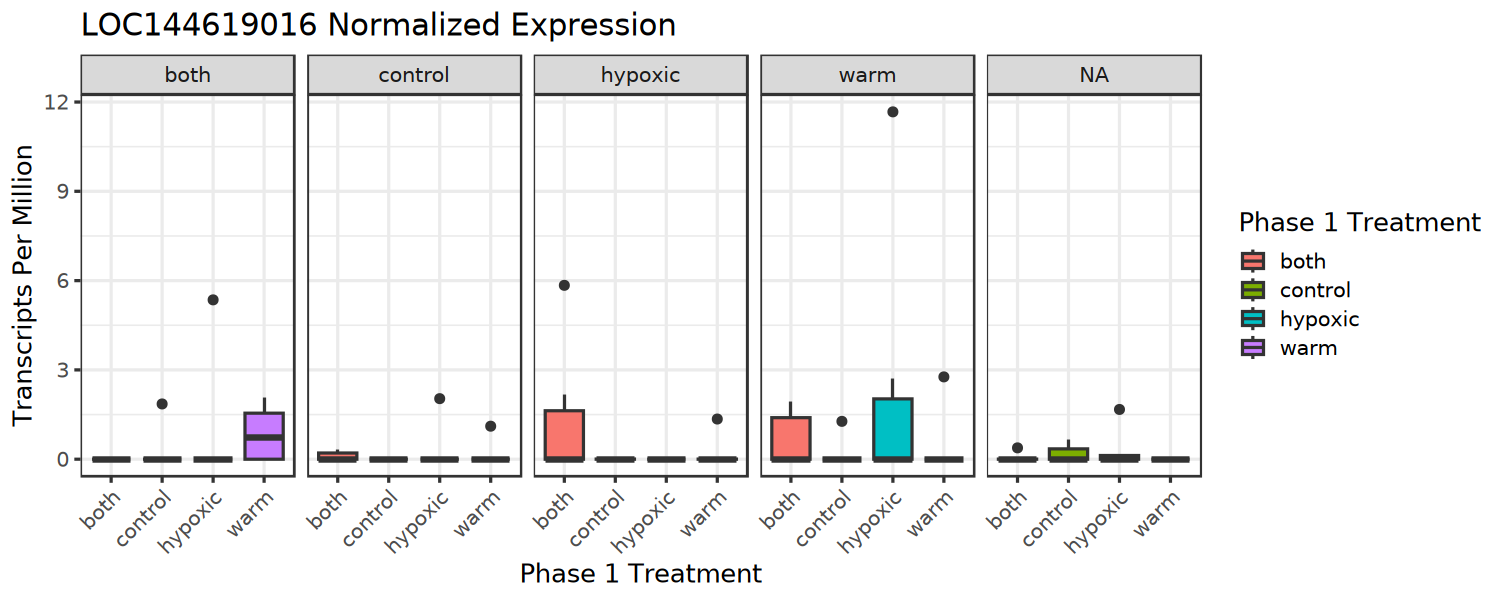

In [59]:
options(repr.plot.height = 5, repr.plot.width = 12.5)

ggplot(chitin_gene, aes(x = Phase1_treatment, y = tpm, fill = Phase1_treatment)) +
geom_boxplot() +
facet_wrap(~Phase2_treatment, nrow = 1) +
labs(title = 'LOC144619016 Normalized Expression',
     y = 'Transcripts Per Million',
     x = 'Phase 1 Treatment',
     fill = 'Phase 1 Treatment') +
theme_bw(base_size = 15) +
theme(axis.text.x = element_text(angle = 45, hjust = 1))

Warning message:
“Removed 3 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


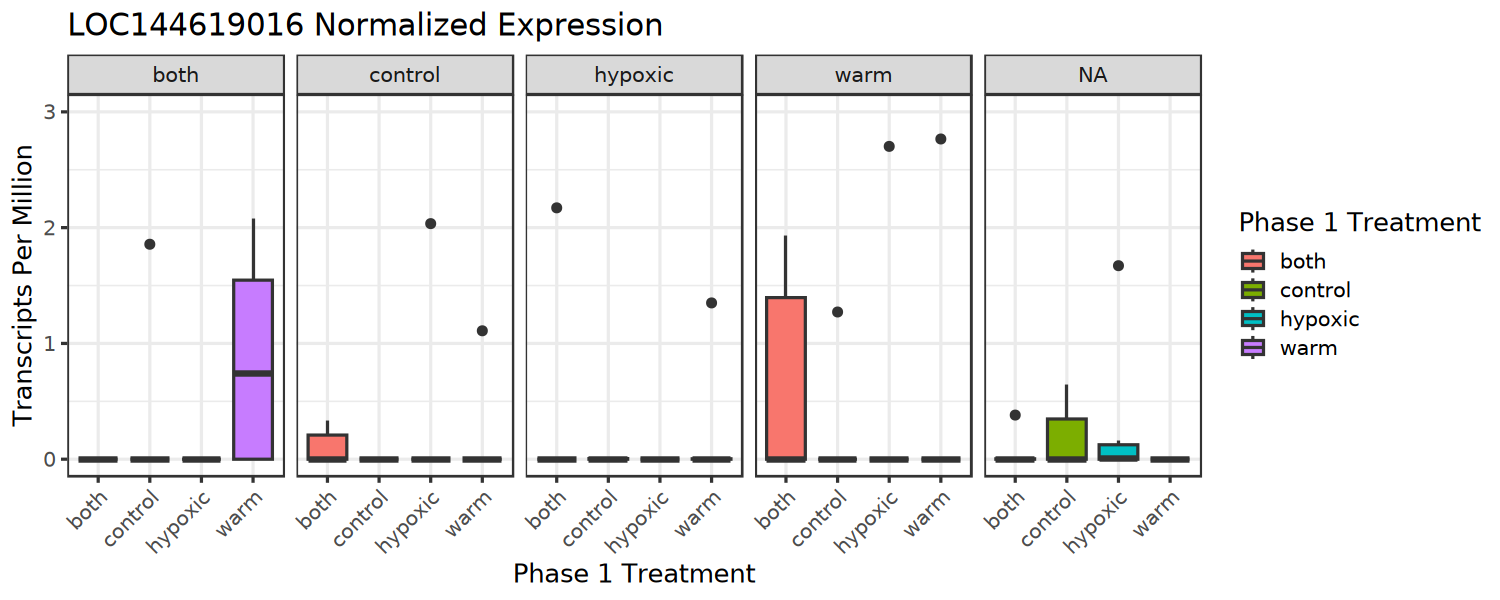

In [60]:
options(repr.plot.height = 5, repr.plot.width = 12.5)

ggplot(chitin_gene, aes(x = Phase1_treatment, y = tpm, fill = Phase1_treatment)) +
geom_boxplot() +
facet_wrap(~Phase2_treatment, nrow = 1) +
labs(title = 'LOC144619016 Normalized Expression',
     y = 'Transcripts Per Million',
     x = 'Phase 1 Treatment',
     fill = 'Phase 1 Treatment') +
theme_bw(base_size = 15) +
ylim(0,3) +
theme(axis.text.x = element_text(angle = 45, hjust = 1))